### Model Training

After completing feature engineering, machine learning models were trained using the updated dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib
import mlflow
import mlflow.sklearn
mlflow.lightgbm.autolog(disable=True)
import json
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
X_train = pd.read_csv("../data/X_train_fe.csv")
X_test = pd.read_csv("../data/X_test_fe.csv")

y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 42)
Test shape: (1409, 42)


In [3]:
numerical_features = X_train.select_dtypes(include=["int64","float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numerical_transformer=Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_transformer=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor=ColumnTransformer([
    ('num',numerical_transformer,numerical_features),
    ('cat',categorical_transformer,categorical_features)
])

pipeline= Pipeline([
    ('preprocessor',preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

In [4]:
pipeline.fit(X_train, y_train)
print("Training complete")

Training complete


In [5]:
y_train_pred_proba=pipeline.predict_proba(X_train)[:,1]
y_test_pred_proba=pipeline.predict_proba(X_test)[:,1]
y_test_pred=pipeline.predict(X_test)

train_auc_log=roc_auc_score(y_train,y_train_pred_proba)
test_auc_log=roc_auc_score(y_test,y_test_pred_proba)

precision_log=precision_score(y_test,y_test_pred)
recall_log=recall_score(y_test,y_test_pred)
f1_log=f1_score(y_test,y_test_pred)

print("Logistic Regression Results:")
print(f"Train ROC-AUC: {train_auc_log:.4f}")
print(f"Test ROC-AUC: {test_auc_log:.4f}")
print(f"Test Precision: {precision_log:.4f}")
print(f"Test Recall: {recall_log:.4f}")
print(f"Test F1-Score: {f1_log:.4f}")

Logistic Regression Results:
Train ROC-AUC: 0.8449
Test ROC-AUC: 0.8397
Test Precision: 0.5103
Test Recall: 0.7914
Test F1-Score: 0.6205


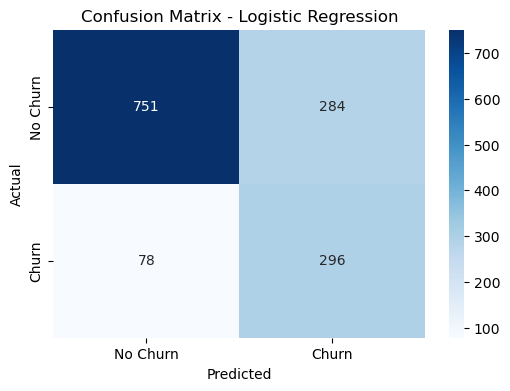

In [6]:
cm_log = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression Results

The Logistic Regression model achieved a **Train ROC-AUC of 0.8449** and a **Test ROC-AUC of 0.8397**, indicating very similar performance between training and test sets. This suggests that the model generalizes well and does not show strong signs of overfitting.

On the test set, the model achieved:
- **Precision:** 0.5103  
- **Recall:** 0.7914  
- **F1-score:** 0.6205  

The relatively high **recall (0.7914)** shows that the model successfully identifies a large proportion of customers who actually churn. However, the **precision (0.5103)** indicates that some customers predicted as churn may not actually leave.

Overall, the model performs well at detecting churners, which is valuable in churn prediction scenarios where identifying potential churn customers is important.

In [7]:
X_train_lgb=X_train.copy()
X_test_lgb = X_test.copy()

cat_mappings={}

for col in categorical_features:
    unique_vals=X_train_lgb[col].dropna().unique()
    mapping = {val: ide for ide, val in enumerate(unique_vals) }
    cat_mappings[col]=mapping
    X_train_lgb[col] = X_train_lgb[col].map(mapping)
    X_test_lgb[col] = X_test_lgb[col].map(mapping)

In [8]:
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    class_weight='balanced',
    verbose=-1
)
lgb_model.fit(X_train_lgb, y_train, eval_set=[(X_test_lgb, y_test)], eval_metric='auc')
print("Training complete")

Training complete


In [9]:
y_train_pred_proba_lgb = lgb_model.predict_proba(X_train_lgb)[:,1]
y_test_pred_proba_lgb = lgb_model.predict_proba(X_test_lgb)[:,1]
y_test_pred_lgb = lgb_model.predict(X_test_lgb)

train_auc_lgb = roc_auc_score(y_train, y_train_pred_proba_lgb)
test_auc_lgb = roc_auc_score(y_test, y_test_pred_proba_lgb)

precision_lgb = precision_score(y_test, y_test_pred_lgb)
recall_lgb = recall_score(y_test, y_test_pred_lgb)
f1_lgb = f1_score(y_test, y_test_pred_lgb)

print("LightGBM Results:")
print(f"Train ROC-AUC: {train_auc_lgb:.4f}")
print(f"Test ROC-AUC: {test_auc_lgb:.4f}")
print(f"Test Precision: {precision_lgb:.4f}")
print(f"Test Recall: {recall_lgb:.4f}")
print(f"Test F1-Score: {f1_lgb:.4f}")

LightGBM Results:
Train ROC-AUC: 0.9880
Test ROC-AUC: 0.8305
Test Precision: 0.5544
Test Recall: 0.7219
Test F1-Score: 0.6272


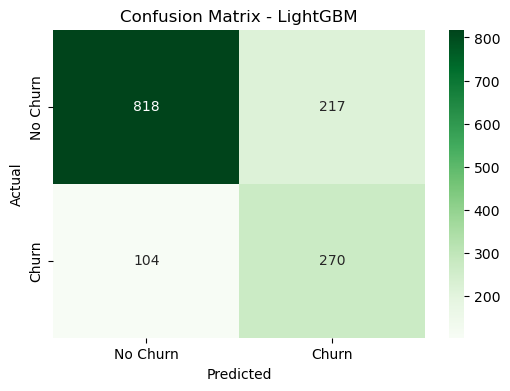

In [10]:
cm_lgb = confusion_matrix(y_test, y_test_pred_lgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### LightGBM Results

The LightGBM model achieved a **Train ROC-AUC of 0.9880** and a **Test ROC-AUC of 0.8305**. The large gap between training and test AUC suggests that the model may be **overfitting the training data**.

On the test set, the model achieved:
- **Precision:** 0.5544  
- **Recall:** 0.7219  
- **F1-score:** 0.6272  

Compared to Logistic Regression, LightGBM has **higher precision (0.5544 vs 0.5103)**, meaning its churn predictions are more accurate. However, it has **lower recall (0.7219 vs 0.7914)**, indicating that it misses more customers who actually churn.

Overall, LightGBM provides slightly better precision and F1-score, but Logistic Regression is more effective at identifying churn customers.

In [11]:
results= pd.DataFrame({
    "Model":["Logistic Regression", "LightGBM"],
    "Train AUC" : [train_auc_log,train_auc_lgb],
    "Test AUC" : [test_auc_log,test_auc_lgb],
    "Precision" : [precision_log,precision_lgb],
    "Recall" : [recall_log,recall_lgb],
    "F1 Score" : [f1_log,f1_lgb]
})

print(results)

                 Model  Train AUC  Test AUC  Precision    Recall  F1 Score
0  Logistic Regression   0.844934  0.839699   0.510345  0.791444  0.620545
1             LightGBM   0.988043  0.830510   0.554415  0.721925  0.627178


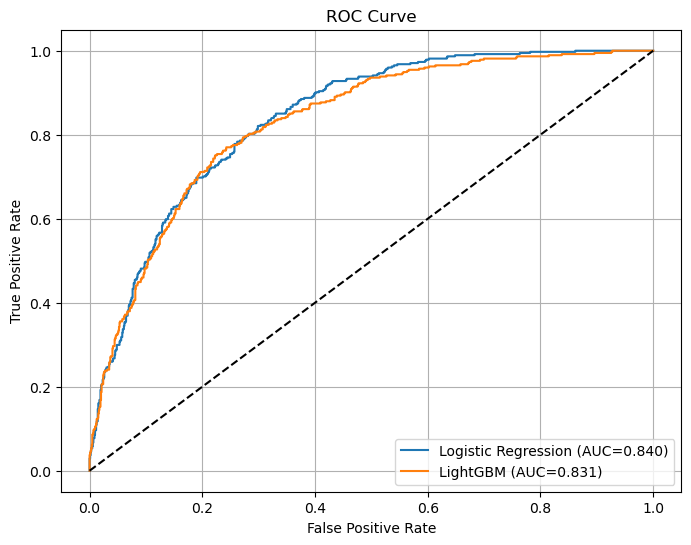

In [12]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_test_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test,y_test_pred_proba_lgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={test_auc_log:.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={test_auc_lgb:.3f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()



### Model Comparison and Business Interpretation

The Logistic Regression model showed consistent and stable results on both training and test data. This means it generalizes well. It was also good at identifying customers who are likely to churn, which can help detect high-risk customers.

LightGBM, on the other hand, is more complex but performed better overall. It can capture non-linear relationships between features and churn behavior, making its predictions more balanced.

From a business perspective, accurate churn predictions are very important. Correct predictions help companies focus on the right customers and use resources efficiently. Reducing wrong predictions also ensures that retention efforts are applied effectively.

In conclusion, **LightGBM was selected as the final model for this project because it provides more balanced and reliable predictions.**.

In [13]:
feature_importance = pd.DataFrame({
    "feature":X_train.columns,
    "importance":lgb_model.feature_importances_
}).sort_values("importance",ascending=False)

print(feature_importance.head())

               feature  importance
5    Charge_Difference        2205
3         TotalCharges        1836
15  charge_per_service        1720
2       MonthlyCharges        1589
1               tenure        1435


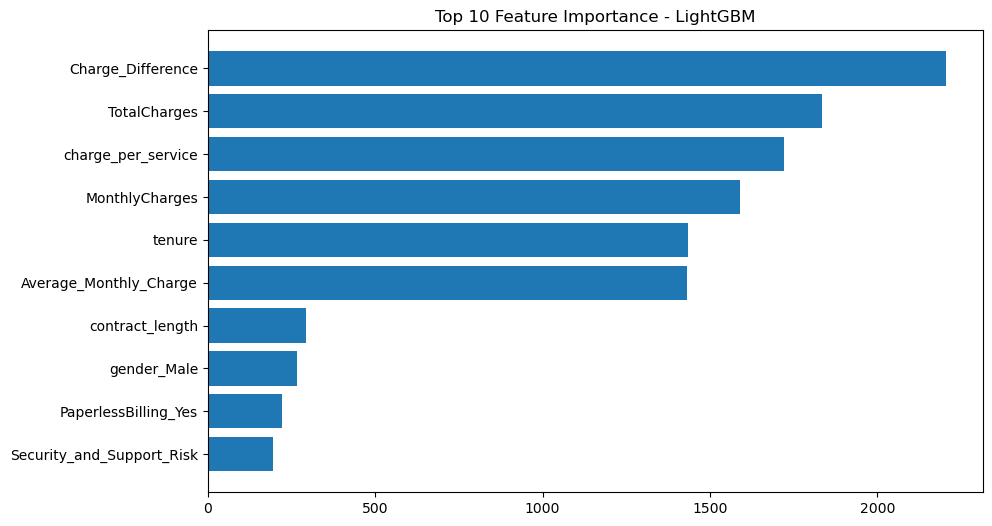

In [14]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - LightGBM")
plt.show()

Hyperparameter Tuning (LightGBM)

In [17]:
X_train = pd.get_dummies(X_train, columns=['Tenure_Cohorts'], drop_first=True)
param_grid = {
    "n_estimators":[300,500],
    "learning_rate":[0.01,0.05],
    "max_depth":[5,7,9],
    "num_leaves":[31,50]
    
}

grid = GridSearchCV(
    LGBMClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'num_leaves': 31}
Best CV Score: 0.8448202420550902


In [18]:
best_lgb_model = grid.best_estimator_

In [23]:
os.makedirs("../models", exist_ok=True)

joblib.dump(pipeline, "../models/logistic_fe_model.pkl")
joblib.dump(best_lgb_model, "../models/lightgbm_fe_model.pkl")

print("Models saved")

Models saved


In [24]:
joblib.dump(list(X_train.columns), "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [25]:
mlflow_tracking_uri = os.path.join(os.getcwd(), "mlruns")

mlflow.set_tracking_uri(f"file:///{mlflow_tracking_uri}")

mlflow.set_experiment("feature_engineered_models")

<Experiment: artifact_location='file:///C:\\Users\\NOKTA\\OneDrive\\Masaüstü\\Churn\\notebooks\\mlruns/226696954492777509', creation_time=1772971003233, experiment_id='226696954492777509', last_update_time=1772971003233, lifecycle_stage='active', name='feature_engineered_models', tags={}>

In [27]:
with mlflow.start_run(run_name="logistic_fe"):

    mlflow.log_param("model","LogisticRegression")

    mlflow.log_metric("train_auc", train_auc_log)
    mlflow.log_metric("test_auc", test_auc_log)
    mlflow.log_metric("precision", precision_log)
    mlflow.log_metric("recall", recall_log)
    mlflow.log_metric("f1", f1_log)

    mlflow.sklearn.log_model(pipeline, name = "model")

with mlflow.start_run(run_name="lightgbm_fe"):

    mlflow.log_param("model","LightGBM")

    mlflow.log_metric("train_auc", train_auc_lgb)
    mlflow.log_metric("test_auc", test_auc_lgb)
    mlflow.log_metric("precision", precision_lgb)
    mlflow.log_metric("recall", recall_lgb)
    mlflow.log_metric("f1", f1_lgb)

    mlflow.sklearn.log_model(best_lgb_model, name = "model")    